In [3]:
%pip install pymupdf spacy pandas scikit-learn
%python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 786.3 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 837.7 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.3/137.3 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.1/812.1 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.5/657.5 kB 1.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 1.6 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.1/64.1 kB 1.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [9]:
%pip install --upgrade pip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.2 MB/s eta 0:00:0000:0100:010m
  Attempting uninstall: pip
    Found existing installation: pip 22.3
    Uninstalling pip-22.3:
      Successfully uninstalled pip-22.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os

# Load the dataset
# If the file is in the same folder, just use 'Resume.csv'
file_path = 'archive-2/Resume/Resume.csv' 

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Total Resumes: {len(df)}")
    print(df.head(3))
else:
    print("Error: Resume.csv not found in the current folder. Please check the file path.")

Dataset loaded successfully!
Total Resumes: 2484
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  


In [3]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text.strip()

# Clean all resumes in the dataframe
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

# Define YOUR Job Description here (You can edit this string)
job_description = """
We are seeking a Software Engineer with proficiency in Python and SQL. 
Experience with Machine Learning, NLP, and cloud platforms like AWS is preferred. 
Strong problem-solving skills and 2 years of experience.
"""
cleaned_jd = clean_text(job_description)

# Define the skills you want to highlight specifically
required_skills = ["python", "sql", "machine learning", "nlp", "aws", "java", "docker", "kubernetes"]

def check_skills(text, skills_list):
    text = text.lower()
    found = [skill for skill in skills_list if skill in text]
    missing = [skill for skill in skills_list if skill not in text]
    return found, missing

In [4]:
# 1. Similarity Scoring using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
all_texts = [cleaned_jd] + df['cleaned_resume'].tolist()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Compare JD (index 0) with all resumes (index 1 onwards)
scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

# 2. Add Results to DataFrame
df['Match_Score'] = scores * 100

# 3. Apply Skill Check
analysis = df['cleaned_resume'].apply(lambda x: check_skills(x, required_skills))
df['Skills_Found'] = analysis.apply(lambda x: ", ".join(x[0]))
df['Missing_Skills'] = analysis.apply(lambda x: ", ".join(x[1]))

# 4. Final Ranking
# We'll filter for columns that matter for the recruiter
ranked_candidates = df[['ID', 'Category', 'Match_Score', 'Skills_Found', 'Missing_Skills']].sort_values(by='Match_Score', ascending=False)

# Show top 10
print("TOP 10 CANDIDATES:")
ranked_candidates.head(10)

TOP 10 CANDIDATES:


,ID,Category,Match_Score,Skills_Found,Missing_Skills
298,20824105,INFORMATION-TECHNOLOGY,14.486528,"python, aws","sql, machine learning, nlp, java, docker, kube..."
1762,12011623,ENGINEERING,13.018167,"python, sql, machine learning","nlp, aws, java, docker, kubernetes"
1742,51588273,ENGINEERING,11.886694,"sql, java","python, machine learning, nlp, aws, docker, ku..."
297,83816738,INFORMATION-TECHNOLOGY,11.278858,"sql, aws, java","python, machine learning, nlp, docker, kubernetes"
1799,10624813,ENGINEERING,10.741515,"python, sql, aws, java","machine learning, nlp, docker, kubernetes"
1239,27419236,DIGITAL-MEDIA,9.951976,sql,"python, machine learning, nlp, aws, java, dock..."
1142,30863060,CONSULTANT,9.822715,"sql, java","python, machine learning, nlp, aws, docker, ku..."
280,28126340,INFORMATION-TECHNOLOGY,9.590305,"sql, java","python, machine learning, nlp, aws, docker, ku..."
2199,21297521,BANKING,9.513832,"sql, nlp, aws, java, docker, kubernetes","python, machine learning"
1218,21156767,CONSULTANT,9.170589,"python, sql, machine learning, java","nlp, aws, docker, kubernetes"


/var/folders/fy/yf4l2bzj673ghm6zr07l8cbh0000gn/T/ipykernel_28579/4189076975.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


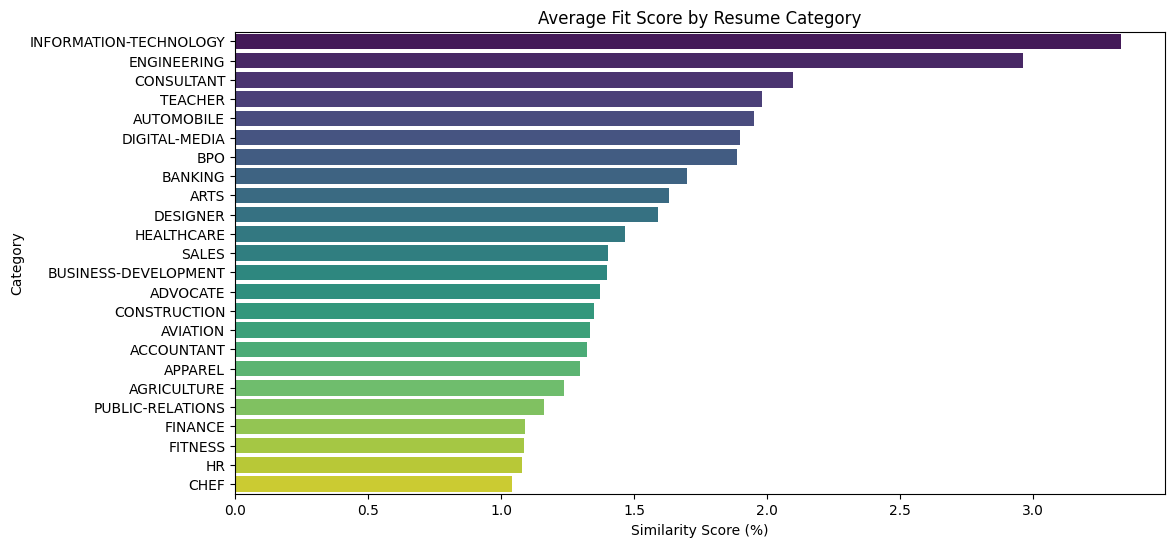

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_categories = df.groupby('Category')['Match_Score'].mean().sort_values(ascending=False)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Average Fit Score by Resume Category')
plt.xlabel('Similarity Score (%)')
plt.ylabel('Category')
plt.show()